<a href="https://colab.research.google.com/github/hjleed/DigitalCoherentSystem_hitham/blob/main/DPQAM_RRC_Pulse_Shaping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Root Raised Cosine Pulse Shaping for Dual-Polarization QAM (DP-QAM)

**Author:** Hitham Jleed @ Ottawa


**Root Raised Cosine (RRC)** pulse shaping for Dual-Polarization Quadrature Amplitude Modulation (DP-QAM), commonly used in coherent optical communication systems. For Education Purpose

**Important practical note:**  
In commercial coherent optical systems the transmitter almost always implements RRC pulse shaping as a **time-domain FIR filter** (exactly what this notebook does).  
At the receiver the matched RRC filter is typically merged into the frequency-domain chromatic-dispersion equalizer (FFT-based).

### Contents
1. RRC filter design
2. DP-QAM symbol generation
3. Pulse shaping (independent per polarization) – time-domain FIR
4. Time-domain, frequency-domain, and constellation visualizations


## 1. Imports

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import upfirdn, welch

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True


## 2. Root Raised Cosine Filter

The RRC filter is the standard pulse-shaping filter in coherent systems.  
When the same RRC is used at both transmitter and receiver, the overall response becomes a Raised Cosine filter (zero ISI at symbol instants).


In [18]:
def rrc_filter(span: int, sps: int, alpha: float, normalize: str = 'peak') -> np.ndarray:
    """
    Generate a Root-Raised-Cosine (RRC) filter.

    Parameters
    ----------
    span : int
        Filter length in symbols (recommended: 8–16)
    sps : int
        Samples per symbol
    alpha : float
        Roll-off factor (0 < alpha ≤ 1). Typical values in coherent optics: 0.1–0.3
    normalize : str
        'peak'  → max(|h|) = 1   (recommended for Tx pulse-shaping demos)
        'energy'→ sum(h²) = 1    (common for matched-filter theory)

    Returns
    -------
    h : ndarray
        RRC impulse response
    """
    N = span * sps
    t = np.arange(-N/2, N/2 + 1) / sps          # time in symbol periods

    h = np.zeros_like(t, dtype=float)

    for i, ti in enumerate(t):
        if np.isclose(ti, 0.0):
            h[i] = 1.0 + alpha * (4/np.pi - 1)
        elif np.isclose(abs(ti), 1/(4*alpha)):
            h[i] = (alpha / np.sqrt(2)) * (
                (1 + 2/np.pi) * np.sin(np.pi/(4*alpha)) +
                (1 - 2/np.pi) * np.cos(np.pi/(4*alpha))
            )
        else:
            num = (np.sin(np.pi * ti * (1 - alpha)) +
                   4 * alpha * ti * np.cos(np.pi * ti * (1 + alpha)))
            den = np.pi * ti * (1 - (4 * alpha * ti)**2)
            h[i] = num / den

    if normalize == 'peak':
        h = h / np.max(np.abs(h))
    elif normalize == 'energy':
        h = h / np.sqrt(np.sum(h**2))
    else:
        raise ValueError("normalize must be 'peak' or 'energy'")
    return h


## 3. System Parameters

In [19]:
# Modulation & sampling
M           = 16          # 16-QAM
sps         = 8           # samples per symbol
span        = 10          # filter span in symbols
alpha       = 0.20        # roll-off factor (typical for coherent systems)
num_symbols = 2**12       # symbols per polarization

print(f"Modulation      : {M}-QAM")
print(f"Samples/symbol  : {sps}")
print(f"Filter span     : {span} symbols")
print(f"Roll-off (α)    : {alpha}")
print(f"Symbols / pol   : {num_symbols}")


Modulation      : 16-QAM
Samples/symbol  : 8
Filter span     : 10 symbols
Roll-off (α)    : 0.2
Symbols / pol   : 4096


## 4. Generate RRC Filter

In [20]:
h_rrc = rrc_filter(span, sps, alpha, normalize='peak')

print(f"Filter length : {len(h_rrc)} taps")
print(f"Peak value    : {np.max(np.abs(h_rrc)):.6f}  (should be 1.0)")
print(f"Filter energy : {np.sum(h_rrc**2):.4f}")


Filter length : 81 taps
Peak value    : 1.000000  (should be 1.0)
Filter energy : 7.1896


## 5. Generate Dual-Polarization QAM Symbols

Each polarization carries independent complex QAM symbols with unit average power.


In [21]:
def generate_qam_symbols(M: int, num_symbols: int) -> np.ndarray:
    """Generate unit-energy square QAM constellation symbols."""
    m = int(np.sqrt(M))
    real = 2 * np.random.randint(0, m, num_symbols) - (m - 1)
    imag = 2 * np.random.randint(0, m, num_symbols) - (m - 1)
    symbols = (real + 1j * imag) / np.sqrt((M - 1) * 2 / 3)  # normalize to unit average power
    return symbols

np.random.seed(42)  # for reproducibility

symbols_x = generate_qam_symbols(M, num_symbols)
symbols_y = generate_qam_symbols(M, num_symbols)

print(f"X-pol symbols shape : {symbols_x.shape}")
print(f"Y-pol symbols shape : {symbols_y.shape}")
print(f"Average power X-pol : {np.mean(np.abs(symbols_x)**2):.4f}")
print(f"Average power Y-pol : {np.mean(np.abs(symbols_y)**2):.4f}")


X-pol symbols shape : (4096,)
Y-pol symbols shape : (4096,)
Average power X-pol : 1.0113
Average power Y-pol : 0.9938


## 6. Pulse Shaping (Transmitter – Time-Domain FIR)

In real coherent optical transmitters, RRC pulse shaping is performed by a short **time-domain FIR filter**.

We use `scipy.signal.upfirdn`, which efficiently combines zero-insertion upsampling and FIR filtering — the standard and practical way to implement the transmitter pulse shaper.

**Note:** A single RRC does **not** satisfy the Nyquist criterion. Residual inter-symbol interference (ISI) is therefore expected when sampling after only the Tx filter. Zero ISI is obtained only after the matched filter at the receiver (Tx RRC + Rx RRC = Raised Cosine).


In [22]:
def pulse_shape(symbols: np.ndarray, h: np.ndarray, sps: int) -> np.ndarray:
    """
    Transmitter-side RRC pulse shaping using time-domain FIR.

    This is the method used in commercial optical DSP ASICs
    (short FIR, typically 16–64 taps at 1.25–2 samples/symbol).
    """
    # upfirdn performs zero-insertion upsampling + convolution in one efficient step
    shaped = upfirdn(h, symbols, up=sps)
    return shaped

tx_x = pulse_shape(symbols_x, h_rrc, sps)
tx_y = pulse_shape(symbols_y, h_rrc, sps)

# Dual-polarization signal: shape (2, n_samples)
tx_dp = np.vstack([tx_x, tx_y])

print(f"X-pol samples      : {tx_x.shape}")
print(f"Y-pol samples      : {tx_y.shape}")
print(f"DP signal shape    : {tx_dp.shape}")
print(f"Total duration     : {tx_x.size / sps:.1f} symbol periods")


X-pol samples      : (32841,)
Y-pol samples      : (32841,)
DP signal shape    : (2, 32841)
Total duration     : 4105.1 symbol periods


## 7. Visualizations

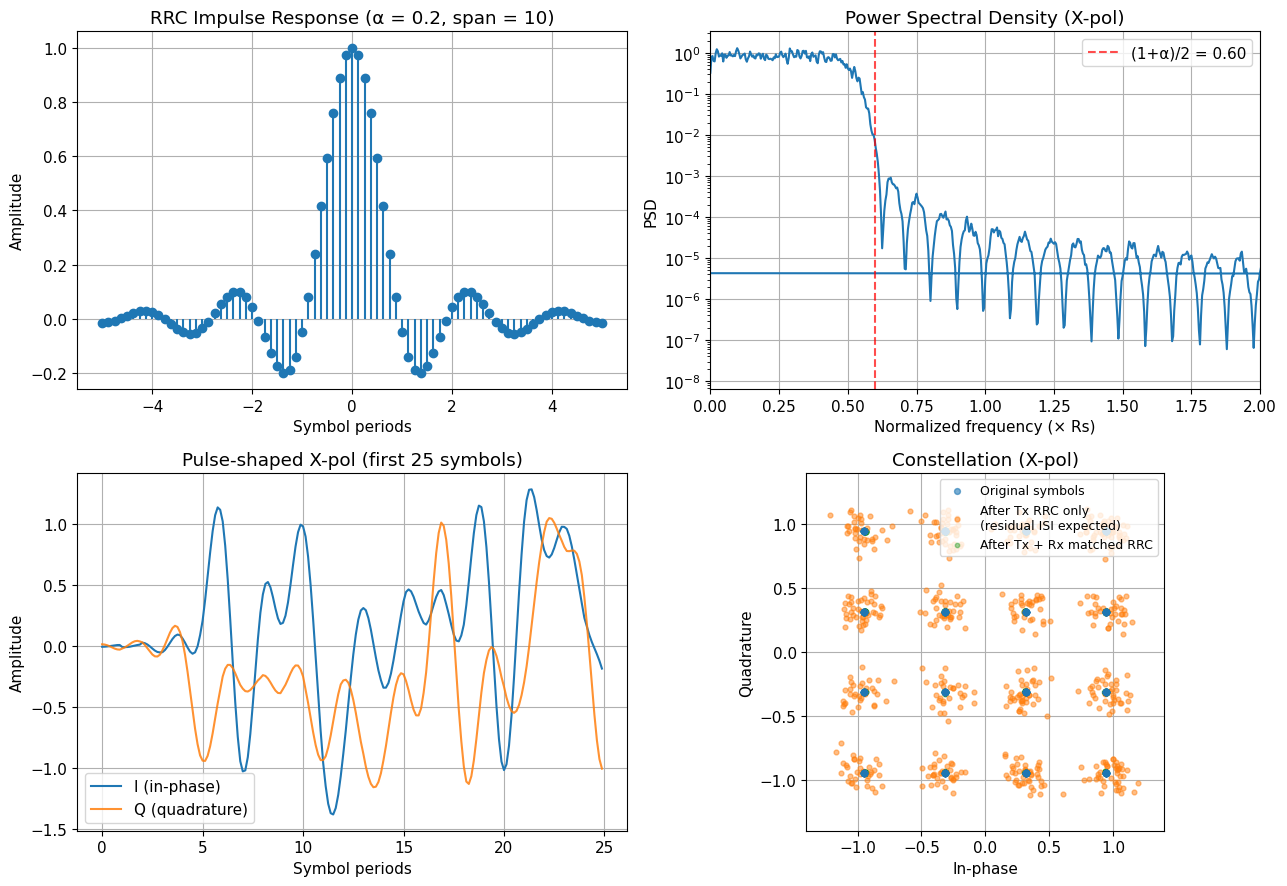

Sampling delay used          : 40 samples
RMS error (Tx RRC only)      : 0.1179
RMS error (after matched MF) : 0.0086


In [23]:
fig, axs = plt.subplots(2, 2, figsize=(13, 9))

# 1. RRC impulse response
t = (np.arange(len(h_rrc)) - (len(h_rrc)-1)/2) / sps
axs[0, 0].stem(t, h_rrc, basefmt=" ")
axs[0, 0].set_title(f'RRC Impulse Response (α = {alpha}, span = {span})')
axs[0, 0].set_xlabel('Symbol periods')
axs[0, 0].set_ylabel('Amplitude')
axs[0, 0].set_xlim(-span/2 - 0.5, span/2 + 0.5)

# 2. Power spectrum (X-pol)
f, Pxx = welch(tx_x, fs=sps, nperseg=2048, return_onesided=True)
axs[0, 1].semilogy(f, Pxx)
axs[0, 1].set_title('Power Spectral Density (X-pol)')
axs[0, 1].set_xlabel('Normalized frequency (× Rs)')
axs[0, 1].set_ylabel('PSD')
axs[0, 1].set_xlim(0, 2)
axs[0, 1].axvline(0.5*(1+alpha), color='r', ls='--', alpha=0.7, label=f'(1+α)/2 = {0.5*(1+alpha):.2f}')
axs[0, 1].legend()

# 3. Time-domain waveform (first 25 symbols)
n_show = 25 * sps
time_axis = np.arange(n_show) / sps
axs[1, 0].plot(time_axis, np.real(tx_x[:n_show]), label='I (in-phase)')
axs[1, 0].plot(time_axis, np.imag(tx_x[:n_show]), label='Q (quadrature)', alpha=0.85)
axs[1, 0].set_title('Pulse-shaped X-pol (first 25 symbols)')
axs[1, 0].set_xlabel('Symbol periods')
axs[1, 0].set_ylabel('Amplitude')
axs[1, 0].legend()

# 4. Constellation comparison
# Correct sampling delay = location of the filter peak
delay = np.argmax(np.abs(h_rrc))
rx_tx_only = tx_x[delay::sps][:num_symbols]

# Also apply matched filter (Rx RRC) for comparison
rx_matched = upfirdn(h_rrc, tx_x, up=1)          # matched filtering
delay_mf = 2 * delay                               # two filters → twice the delay
rx_after_mf = rx_matched[delay_mf::sps][:num_symbols]

# Scale matched-filter output so average power ≈ 1 (for fair visual comparison)
rx_after_mf = rx_after_mf / np.sqrt(np.mean(np.abs(rx_after_mf)**2))

axs[1, 1].scatter(np.real(symbols_x[:600]), np.imag(symbols_x[:600]),
                  s=18, alpha=0.6, label='Original symbols', zorder=3)
axs[1, 1].scatter(np.real(rx_tx_only[:600]), np.imag(rx_tx_only[:600]),
                  s=12, alpha=0.5, label='After Tx RRC only\n(residual ISI expected)', zorder=2)
axs[1, 1].scatter(np.real(rx_after_mf[:600]), np.imag(rx_after_mf[:600]),
                  s=10, alpha=0.45, label='After Tx + Rx matched RRC', zorder=1)

axs[1, 1].set_title('Constellation (X-pol)')
axs[1, 1].set_xlabel('In-phase')
axs[1, 1].set_ylabel('Quadrature')
axs[1, 1].set_aspect('equal')
axs[1, 1].legend(loc='upper right', fontsize=9)
axs[1, 1].set_xlim(-1.4, 1.4)
axs[1, 1].set_ylim(-1.4, 1.4)

plt.tight_layout()
plt.show()

print(f"Sampling delay used          : {delay} samples")
print(f"RMS error (Tx RRC only)      : {np.sqrt(np.mean(np.abs(rx_tx_only - symbols_x)**2)):.4f}")
print(f"RMS error (after matched MF) : {np.sqrt(np.mean(np.abs(rx_after_mf - symbols_x)**2)):.4f}")


### Optional: Time-domain view of both polarizations

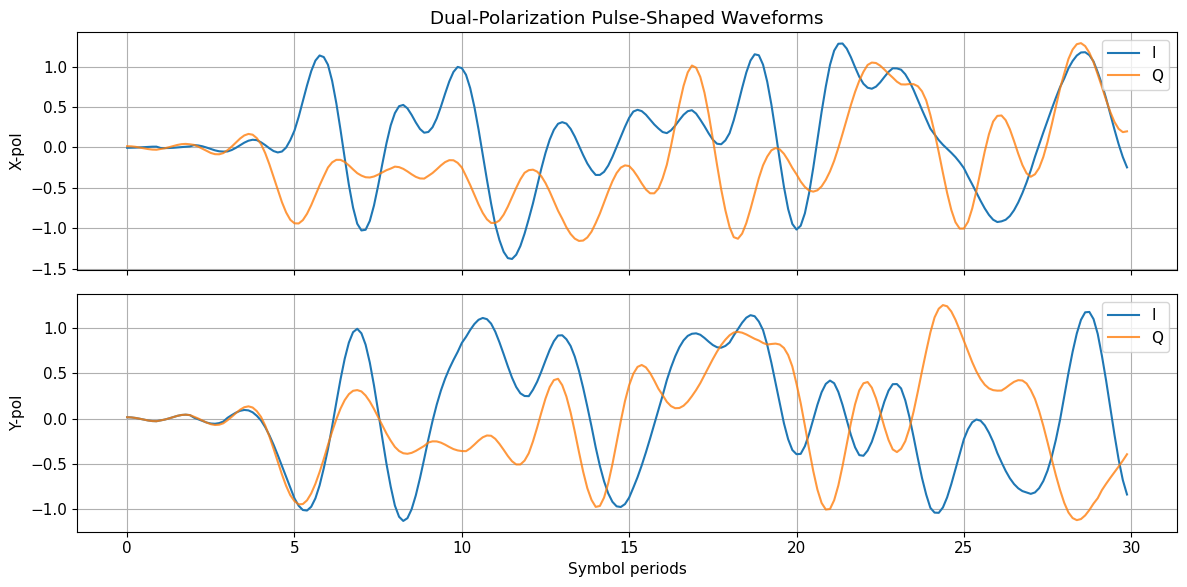

In [16]:
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

n_show = 30 * sps
t = np.arange(n_show) / sps

axs[0].plot(t, np.real(tx_x[:n_show]), label='I')
axs[0].plot(t, np.imag(tx_x[:n_show]), label='Q', alpha=0.8)
axs[0].set_ylabel('X-pol')
axs[0].set_title('Dual-Polarization Pulse-Shaped Waveforms')
axs[0].legend(loc='upper right')

axs[1].plot(t, np.real(tx_y[:n_show]), label='I')
axs[1].plot(t, np.imag(tx_y[:n_show]), label='Q', alpha=0.8)
axs[1].set_ylabel('Y-pol')
axs[1].set_xlabel('Symbol periods')
axs[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


## 8. Practical Notes for Coherent Optical Systems



### How RRC is implemented in real systems

| Side | Implementation | Reason |
|------|----------------|--------|
| **Transmitter** | Time-domain FIR (short, 16–64 taps) | Continuous symbol stream, low oversampling (1.2–2 sps), power & latency efficient |
| **Receiver** | Frequency-domain (FFT × mask × IFFT), usually merged with CD compensation | Chromatic dispersion requires thousands of taps → pure TD FIR is impractical |

This notebook demonstrates the **transmitter-side** implementation (time-domain FIR), which is the approach used in commercial coherent DSP ASICs.

### Typical parameter ranges

| Parameter       | Typical Range       | Comment |
|-----------------|---------------------|---------|
| Roll-off α      | 0.05 – 0.25         | Most 400G/800G systems use ≤ 0.2 |
| Filter span     | 8 – 16 symbols      | Longer span → lower residual ISI, higher complexity |
| Samples/symbol  | 1.25 – 2 (ASIC)     | Simulation often uses 4–8 sps for clarity |

### Integration order in a transmitter DSP chain
```
Bits → FEC Encoder → Mapper (QAM) → Pulse shaping (RRC FIR) → Pre-emphasis / CD pre-comp → DAC → IQ Modulator → Polarization Multiplexing
```
